# 03 - Preprocessing

Clean ticket text, prepare features, and create reusable preprocessing artifacts.

# Customer Support Ticket Preprocessing

## Objective
This notebook demonstrates end-to-end data preprocessing on a customer support ticket dataset.

- Data Understanding
- Duplicate Removal
- Missing Value Treatment
- Data Standardization
- Email Validation
- Data Type Conversion
- Text Preprocessing
- Outlier Detection
- Feature Engineering
- Encoding
- Exporting Clean Dataset

In [1]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", 10)
path = r"D:\customer_support-ai\data\customer_support_tickets.csv"
df = pd.read_csv(path)
df


,Ticket ID,Customer Name,Customer Email,Product Purchased,Date of Purchase,...,Ticket Description,Ticket Priority,First Response Time,Time to Resolution,Customer Satisfaction Rating
0,TKT-1001,Arjun Sharma,invalid_email,Wireless Mouse,03-12-2025,...,Need information about warranty,Low,8.3,214.3,1
1,TKT-1002,Isha Krishnan,isha.krishnan5@gmail.com,laptop pro 15,01-08-2025,...,Bluetooth connection drops frequently.,Low,7.0,172.4,5
2,TKT-1003,Devansh Joshi,invalid_email,gaming console z,03-09-2025,...,unacceptable delay! Need information about wa...,High,5.1,192.4,3
3,TKT-1004,Devansh Sharma,devansh.sharma3@gmail.com,wireless mouse,03-07-2025,...,Delivery arrived much later than expected.,Low,18.8,103.8,5
4,TKT-1005,Ananya Patel,invalid_email,smartwatch v2,02-01-2025,...,Not compatible with my device.,Low,18.8,131.0,4
...,...,...,...,...,...,...,...,...,...,...,...
336,TKT-1337,Ananya Roy,ananya.r6@gmail.com,fitness band,03-04-2025,...,App setup,Low,9.8,112.3,4
337,TKT-1338,Suresh Kumar,suresh.k7@yahoo.com,gaming mouse,03-05-2025,...,Hardware query,Low,16.2,160.1,3
338,TKT-1339,Kavita Reddy,kavita.r8@gmail.com,wireless earbud,03-06-2025,...,LED indicator,Low,13.7,145.9,5
339,TKT-1340,Deepa Joshi,deepa.j9@outlook.com,smart plug,03-07-2025,...,Feature request,Low,20.1,205.6,4


## Data Understanding

Before cleaning data, we must understand:

- Number of Rows
- Number of Columns
- Data Types
- Missing Values
- Duplicate Records

In datasets or data structures, NaN stands for "Not a Number" and indicates missing, undefined, or non-applicable values for certain fields in a ticketing system.

In [73]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 341 entries, 0 to 340
Data columns (total 12 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Ticket ID                     341 non-null    object 
 1   Customer Name                 341 non-null    object 
 2   Customer Email                341 non-null    object 
 3   Product Purchased             341 non-null    object 
 4   Date of Purchase              341 non-null    object 
 5   Ticket Type                   341 non-null    object 
 6   Ticket Subject                341 non-null    object 
 7   Ticket Description            341 non-null    object 
 8   Ticket Priority               341 non-null    object 
 9   First Response Time           341 non-null    float64
 10  Time to Resolution            341 non-null    float64
 11  Customer Satisfaction Rating  341 non-null    int64  
dtypes: float64(2), int64(1), object(9)
memory usage: 32.1+ KB


In [74]:
df.describe(include='all')

,Ticket ID,Customer Name,Customer Email,Product Purchased,Date of Purchase,...,Ticket Description,Ticket Priority,First Response Time,Time to Resolution,Customer Satisfaction Rating
count,341,341,341,341,341,...,341,341,341.000000,341.000000,341.000000
unique,341,125,200,15,44,...,74,3,NaN,NaN,NaN
top,TKT-1001,Devansh Iyer,invalid_email,smartwatch v2,3/18/2025,...,unacceptable delay! Item damaged during transi...,High,NaN,NaN,NaN
freq,1,12,105,81,32,...,29,172,NaN,NaN,NaN
mean,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,10.872141,165.434897,3.055718
std,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,7.489916,41.265295,1.430694
min,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,0.200000,72.400000,1.000000
25%,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,2.400000,134.000000,2.000000
50%,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,11.300000,166.400000,3.000000
75%,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,17.200000,196.200000,4.000000


In [75]:
print("Missing Values")

df.isnull().sum()

Missing Values


Ticket ID                       0
Customer Name                   0
Customer Email                  0
Product Purchased               0
Date of Purchase                0
Ticket Type                     0
Ticket Subject                  0
Ticket Description              0
Ticket Priority                 0
First Response Time             0
Time to Resolution              0
Customer Satisfaction Rating    0
dtype: int64

## Duplicate Removal

Duplicate records may:

- Bias analysis
- Affect model performance
- Increase storage cost

In [76]:
duplicate_count = df.duplicated().sum()

print("Duplicate Records:", duplicate_count)

df = df.drop_duplicates()

print("Shape After Removal:", df.shape)

Duplicate Records: 0
Shape After Removal: (341, 12)


In [77]:
df.columns = (
    df.columns
      .str.lower()
      .str.strip()
      .str.replace(" ", "_")
)

df.columns

Index(['ticket_id', 'customer_name', 'customer_email', 'product_purchased',
       'date_of_purchase', 'ticket_type', 'ticket_subject',
       'ticket_description', 'ticket_priority', 'first_response_time',
       'time_to_resolution', 'customer_satisfaction_rating'],
      dtype='object')

Convert customer names into a standard format.

In [78]:
df["customer_name"] = (
    df["customer_name"]
      .str.strip()
      .str.title()
)

df["customer_name"].head()

0      Arjun Sharma
1     Isha Krishnan
2     Devansh Joshi
3    Devansh Sharma
4      Ananya Patel
Name: customer_name, dtype: object

Validate customer email addresses using Regular Expressions.

In [79]:
email_pattern = r'^[A-Za-z0-9._%+-]+@[A-Za-z0-9.-]+\.[A-Za-z]{2,}$'

invalid_emails = df[
    ~df["customer_email"].str.match(
        email_pattern,
        na=False
    )
]

print("Invalid Emails Found")
display(
    invalid_emails[
        ["ticket_id","customer_email"]
    ]
)


Invalid Emails Found


,ticket_id,customer_email
0,TKT-1001,invalid_email
2,TKT-1003,invalid_email
4,TKT-1005,invalid_email
5,TKT-1006,invalid_email
9,TKT-1010,invalid_email
...,...,...
308,TKT-1309,invalid_email
311,TKT-1312,invalid_email
313,TKT-1314,invalid_email
314,TKT-1315,invalid_email


In [80]:
df.shape

(341, 12)

In [81]:
df = df[
    df["customer_email"]
      .str.match(email_pattern, na=False)
] 
# dropping invalid emails records

print("Shape After Email Validation")
print(df.shape)

Shape After Email Validation
(236, 12)


In [82]:
df.isnull().sum()
# missing value
 

ticket_id                       0
customer_name                   0
customer_email                  0
product_purchased               0
date_of_purchase                0
ticket_type                     0
ticket_subject                  0
ticket_description              0
ticket_priority                 0
first_response_time             0
time_to_resolution              0
customer_satisfaction_rating    0
dtype: int64

In [83]:
# mode impiutation for missing values in categorical columns
df["product_purchased"] = (
    df["product_purchased"]
      .fillna(
          df["product_purchased"].mode()[0]
      )
)

In [84]:
df["first_response_time"] = (
df["first_response_time"]
.fillna(
df["first_response_time"].median()
)
)

In [85]:
df["time_to_resolution"] = (
    df["time_to_resolution"]
      .fillna(
          df["time_to_resolution"].median()
      )
)

In [86]:
df.isnull().sum()

ticket_id                       0
customer_name                   0
customer_email                  0
product_purchased               0
date_of_purchase                0
ticket_type                     0
ticket_subject                  0
ticket_description              0
ticket_priority                 0
first_response_time             0
time_to_resolution              0
customer_satisfaction_rating    0
dtype: int64

Convert columns into appropriate data types.    

In [87]:
df["date_of_purchase"] = pd.to_datetime(
    df["date_of_purchase"],
    errors="coerce"
)

In [88]:
df["first_response_time"] = pd.to_numeric(
    df["first_response_time"],
    errors="coerce"
)

In [89]:
df["time_to_resolution"] = pd.to_numeric(
    df["time_to_resolution"],
    errors="coerce"
)

In [90]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 236 entries, 1 to 340
Data columns (total 12 columns):
 #   Column                        Non-Null Count  Dtype         
---  ------                        --------------  -----         
 0   ticket_id                     236 non-null    object        
 1   customer_name                 236 non-null    object        
 2   customer_email                236 non-null    object        
 3   product_purchased             236 non-null    object        
 4   date_of_purchase              73 non-null     datetime64[ns]
 5   ticket_type                   236 non-null    object        
 6   ticket_subject                236 non-null    object        
 7   ticket_description            236 non-null    object        
 8   ticket_priority               236 non-null    object        
 9   first_response_time           236 non-null    float64       
 10  time_to_resolution            236 non-null    float64       
 11  customer_satisfaction_rating  236 non

Product name standardization

In [91]:
# 1. Clean & normalize column first
df["product_purchased"] = (
    df["product_purchased"]
    .astype(str)
    .str.lower()
    .str.replace(r"[^a-zA-Z0-9\s]", " ", regex=True)  # Strip special chars
    .str.replace(r"\s+", " ", regex=True)             # Collapse extra spaces
    .str.strip()
)

# 2. Map normalized strings to clean display names
product_mapping = {
    "laptop pro 15": "Laptop Pro 15",
    "wireless mouse": "Wireless Mouse",
    "monitor 27 inch": "Monitor 27 Inch",
    "usb c hub": "USB-C Hub",
    "noise cancelling headphones": "Noise Cancelling Headphones"
}

df["product_purchased"] = df["product_purchased"].replace(product_mapping)

In [92]:
df["product_purchased"].value_counts()

product_purchased
smartwatch v2                 57
Wireless Mouse                39
bluetooth speaker             39
4k monitor 27in               34
gaming console z              30
noise canceling headphones    15
Laptop Pro 15                 14
wireless earbud                2
smartwatch                     1
wireless keyboard              1
power bank                     1
fitness band                   1
gaming mouse                   1
smart plug                     1
Name: count, dtype: int64

In [93]:
df["ticket_description"] = (
    df["ticket_description"]
      .str.lower()
)

In [94]:
def clean_text(text):

    text = re.sub(
        r'[^a-zA-Z\s]',
        '',
        str(text)
    )

    return text

df["clean_description"] = (
    df["ticket_description"]
      .apply(clean_text)
)

df[["ticket_description","clean_description"]].head()

,ticket_description,clean_description
1,bluetooth connection drops frequently.,bluetooth connection drops frequently
3,delivery arrived much later than expected.,delivery arrived much later than expected
6,unacceptable delay! item damaged during transi...,unacceptable delay item damaged during transit...
7,order status not updating. (need assistance).,order status not updating need assistance
8,urgent! need more information about warranty. ...,urgent need more information about warranty i ...


In [95]:
df["clean_description"] = (
    df["clean_description"]
      .str.replace(
          r"\s+",
          " ",
          regex=True
      )
      .str.strip()
)
df[["ticket_description", "clean_description"]].head()
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 236 entries, 1 to 340
Data columns (total 13 columns):
 #   Column                        Non-Null Count  Dtype         
---  ------                        --------------  -----         
 0   ticket_id                     236 non-null    object        
 1   customer_name                 236 non-null    object        
 2   customer_email                236 non-null    object        
 3   product_purchased             236 non-null    object        
 4   date_of_purchase              73 non-null     datetime64[ns]
 5   ticket_type                   236 non-null    object        
 6   ticket_subject                236 non-null    object        
 7   ticket_description            236 non-null    object        
 8   ticket_priority               236 non-null    object        
 9   first_response_time           236 non-null    float64       
 10  time_to_resolution            236 non-null    float64       
 11  customer_satisfaction_rating  236 non

<!-- Convert categorical values into numeric values.
Show more lines -->

In [96]:
priority_encoding = {
    "Low":0,
    "Medium":1,
    "High":2,
    "Critical":3
}

df["priority_encoded"] = (
    df["ticket_priority"]
      .map(priority_encoding)
)
# let the customer satisfaction rate be in number additionally we can also do one hot encoding for the same
def categorize(rating):

    if rating <= 2:
        return "Unsatisfied"

    elif rating == 3:
        return "Neutral"

    else:
        return "Satisfied"

df["satisfaction_category"] = (
    df["customer_satisfaction_rating"]
      .apply(categorize)
)

df[
    ["customer_satisfaction_rating",
     "satisfaction_category"]
].head()

,customer_satisfaction_rating,satisfaction_category
1,5,Satisfied
3,5,Satisfied
6,4,Satisfied
7,2,Unsatisfied
8,5,Satisfied


Remove outliers

In [97]:
df.shape

(236, 15)

In [98]:
Q1 = df["time_to_resolution"].quantile(0.25)

Q3 = df["time_to_resolution"].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR

upper_bound = Q3 + 1.5 * IQR

outliers = df[
    (
        df["time_to_resolution"] < lower_bound
    )
    |
    (
        df["time_to_resolution"] > upper_bound
    )
]

print("Outliers Found:", len(outliers))

Outliers Found: 0


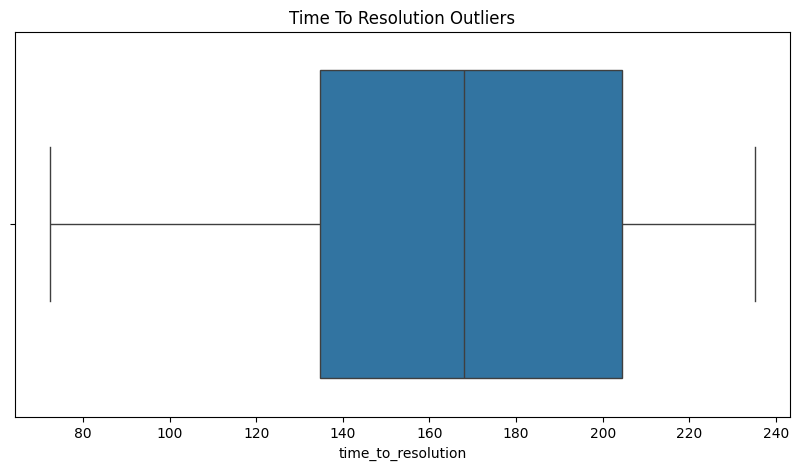

In [99]:
plt.figure(figsize=(10,5))

sns.boxplot(
    x=df["time_to_resolution"]
)

plt.title("Time To Resolution Outliers")

plt.show()

In [100]:
df.columns

Index(['ticket_id', 'customer_name', 'customer_email', 'product_purchased',
       'date_of_purchase', 'ticket_type', 'ticket_subject',
       'ticket_description', 'ticket_priority', 'first_response_time',
       'time_to_resolution', 'customer_satisfaction_rating',
       'clean_description', 'priority_encoded', 'satisfaction_category'],
      dtype='object')

In [101]:
df["word_count"] = df["clean_description"].str.split().str.len()
df["word_count"].head()

1     4
3     6
6    15
7     6
8    15
Name: word_count, dtype: int64

In [102]:
df["exclamation_and_question_count"] = df["clean_description"].astype(str).str.count("!") + df["clean_description"].astype(str).str.count(r"\?")
if not (df["exclamation_and_question_count"] > 0).any():
    df.drop(columns=["exclamation_and_question_count"], inplace=True)

In [103]:
df["purchase_age_days"] = (
    pd.to_datetime("today")
    - pd.to_datetime(df["date_of_purchase"])
).dt.days
df["purchase_age_days"].head()

1    630.0
3    572.0
6      NaN
7    636.0
8    627.0
Name: purchase_age_days, dtype: float64

In [104]:
df["ticket_id"] = df["ticket_id"].astype(str).str.replace("TKT-", "", regex=False)
df["ticket_id"].head()

1    1002
3    1004
6    1007
7    1008
8    1009
Name: ticket_id, dtype: object

In [105]:
df.to_csv(
    "customer_tickets_cleaned.csv",
    index=False
)

print(
    "✅ Preprocessing Completed Successfully"
)

✅ Preprocessing Completed Successfully
